# Setup

In [25]:
exec(open('setup_notebook.py').read())
# Run this cell to fix MuJoCo rendering issues
exec(open('notebook_rendering_fix.py').read())

Exception ignored in: <function Renderer.__del__ at 0x325e61260>
Traceback (most recent call last):
  File "/Users/hamzaiqbal/Documents/projects/MonocularBiomechanics/venv_py311/lib/python3.11/site-packages/mujoco/renderer.py", line 337, in __del__
    self.close()
  File "/Users/hamzaiqbal/Documents/projects/MonocularBiomechanics/venv_py311/lib/python3.11/site-packages/mujoco/renderer.py", line 325, in close
    if self._mjr_context:
       ^^^^^^^^^^^^^^^^^
AttributeError: 'Renderer' object has no attribute '_mjr_context'
Exception ignored in: <function Renderer.__del__ at 0x325e61260>
Traceback (most recent call last):
  File "/Users/hamzaiqbal/Documents/projects/MonocularBiomechanics/venv_py311/lib/python3.11/site-packages/mujoco/renderer.py", line 337, in __del__
    self.close()
  File "/Users/hamzaiqbal/Documents/projects/MonocularBiomechanics/venv_py311/lib/python3.11/site-packages/mujoco/renderer.py", line 325, in close
    if self._mjr_context:
       ^^^^^^^^^^^^^^^^^
Attrib

✓ visualize module imported successfully
✓ forward_kinematics module imported successfully
✓ utils module imported successfully

🎉 All modules imported successfully! Your notebook should work now.
🔧 Fixing MuJoCo rendering...
✓ Trying MUJOCO_GL=osmesa
❌ MUJOCO_GL=osmesa failed: module 'mujoco.gl_context' has no attribute 'GLContext'
✓ Trying MUJOCO_GL=glfw
❌ MUJOCO_GL=glfw failed: module 'mujoco.gl_context' has no attribute 'GLContext'
✓ Trying MUJOCO_GL=egl


Exception ignored in: <function Renderer.__del__ at 0x325e61260>
Traceback (most recent call last):
  File "/Users/hamzaiqbal/Documents/projects/MonocularBiomechanics/venv_py311/lib/python3.11/site-packages/mujoco/renderer.py", line 337, in __del__
    self.close()
  File "/Users/hamzaiqbal/Documents/projects/MonocularBiomechanics/venv_py311/lib/python3.11/site-packages/mujoco/renderer.py", line 325, in close
    if self._mjr_context:
       ^^^^^^^^^^^^^^^^^
AttributeError: 'Renderer' object has no attribute '_mjr_context'
Exception ignored in: <function Renderer.__del__ at 0x325e61260>
Traceback (most recent call last):
  File "/Users/hamzaiqbal/Documents/projects/MonocularBiomechanics/venv_py311/lib/python3.11/site-packages/mujoco/renderer.py", line 337, in __del__
    self.close()
  File "/Users/hamzaiqbal/Documents/projects/MonocularBiomechanics/venv_py311/lib/python3.11/site-packages/mujoco/renderer.py", line 325, in close
    if self._mjr_context:
       ^^^^^^^^^^^^^^^^^
Attrib

❌ MUJOCO_GL=egl failed: module 'mujoco.gl_context' has no attribute 'GLContext'
✓ Trying MUJOCO_GL=disable
❌ MUJOCO_GL=disable failed: module 'mujoco.gl_context' has no attribute 'GLContext'
⚠️  All MuJoCo GL backends failed. Using alternative visualization.
⚠️  MuJoCo rendering failed. Using alternative visualization.
Use the alternative_render_trajectory function instead.

📊 Available functions:
- create_simple_visualization(ang, filename): Creates static plots
- alternative_render_trajectory(ang, filename): Creates animated visualization
- fix_mujoco_rendering(): Tries to fix MuJoCo rendering


In [1]:
import tensorflow as tf

%env MUJOCO_GL=disable

# limit jax and TF from consuming all GPU memory
%env XLA_PYTHON_CLIENT_PREALLOCATE=false

# Check if GPU is available
if tf.config.list_physical_devices('GPU'):
    print("TensorFlow is using the GPU")
else:
    print("TensorFlow is not using the GPU")


gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        # Currently, memory growth needs to be the same across GPUs
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.list_logical_devices("GPU")
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(e)


import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

# Check for available GPU devices
num_devices = jax.local_device_count()
print(f"Found {num_devices} JAX devices:")

env: MUJOCO_GL=disable
env: XLA_PYTHON_CLIENT_PREALLOCATE=false
TensorFlow is not using the GPU
Found 1 JAX devices:


In [2]:
import tensorflow as tf
import tensorflow_hub as hub

from matplotlib import pyplot as plt
import numpy as np

import cv2

In [3]:
# test the body model loads
from monocular_demos.biomechanics_mjx.forward_kinematics import ForwardKinematics

fk = ForwardKinematics()

# Run MeTAbs-ACAE on the video

First upload a video to your colab environment and then select it with the next cell

In [4]:
!ls

docs                     monocular_demos          test_cell.py
IMG_5271.MOV             monocular_demos.egg-info test_environment.py
IMG_5273.MOV             monocular-demo.ipynb     test_fk.py
LICENSE                  pyproject.toml           venv
main.py                  README.md                venv_py311


/opt/homebrew/Cellar/python@3.11/3.11.11/Frameworks/Python.framework/Versions/3.11/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


In [5]:
import os

# List files in current directory
files = os.listdir()
files = [f for f in files if 'mp4' in f or 'MOV' in f or 'MP4' in f]

if len(files) > 1:
    print("Available files:")
    for i, file in enumerate(files):
        print(f"{i+1}. {file}")

    # Prompt user for selection
    # choice = int(input("Enter the number of the file to select: ")) - 1
    choice = 0
    video_filepath = files[choice]

    print(f"You selected: {video_filepath}")

else:

    assert len(files) == 1, "No videos uploaded"

    video_filepath = files[0]


Available files:
1. IMG_5271.MOV
2. IMG_5273.MOV
You selected: IMG_5271.MOV


In [6]:
model = hub.load('https://bit.ly/metrabs_l')  # Takes about 3 minutes

# there are many skeleton formats support by this model. we are selecting one
# compatible with the gait transformer we will use below
skeleton = 'bml_movi_87'

# get the joint names and the edges between them for visualization below
joint_names = model.per_skeleton_joint_names[skeleton].numpy().astype(str)
joint_edges = model.per_skeleton_joint_edges[skeleton].numpy()

In [7]:
# Process video frames with pose detection model
# (frame_batch will be defined in the loop below)

In [8]:
from monocular_demos.utils import video_reader
from tqdm import tqdm

vid, n_frames = video_reader(video_filepath)

accumulated = None
for i, frame_batch in tqdm(enumerate(vid)):
    pred = model.detect_poses_batched(frame_batch, skeleton=skeleton)

    if accumulated is None:
        accumulated = pred

    else:
        # concatenate the ragged tensor along the batch for each element in the dictionary
        for key in accumulated.keys():
            accumulated[key] = tf.concat([accumulated[key], pred[key]], axis=0)

    # if i > 10:
    #     break

79it [28:23, 21.57s/it]


In [ ]:
num_people = [p.shape[0] for p in accumulated['poses2d']]

# assert this is 1 for all the frames (is this what we want?)
# assert len(set(num_people)) == 1

# then extract the information for that person
boxes = np.array([p[0] for p in accumulated['boxes']])
pose3d = np.array([p[0] for p in accumulated['poses3d']])
pose2d = np.array([p[0] for p in accumulated['poses2d']])


In [12]:
# For convenience, save the keypoints in case the notebook crashes or you have to restart

pose3d = np.array([p[0] for p in accumulated['poses3d']])

with open('keypoints3d.npz', 'wb') as f:
    np.savez(f, pose3d)

# Exploration step: try to extract the knee angle over time

Example approach: take the cross product between limb segments

# Now compute kinematics end-to-end using a differentiable body model

This uses an implicit representation $f_\theta: t \rightarrow \theta \in \mathbb R^{40}$, which is then passed through the forward kinematic model to get the predicted 3D keypoints: $\mathcal M_\beta: \theta \rightarrow \mathbf y \in \mathbb R^{87 \times 3}$.

We optimize the difference between the predicted 3D keypoints and the detected 3D keypoints.

In [13]:
with open('keypoints3d.npz', 'rb') as f:
    pose3d = np.load(f, allow_pickle=True)['arr_0']

In [14]:
pose3d = np.array([p[0] for p in accumulated['poses3d']])

In [15]:
from jax import numpy as jnp

# convert pose to m
pose = pose3d
pose = pose[:, :, [0, 2, 1]]
pose[:, :, 2] *= -1
pose /= 1000.0

pose = pose - np.min(pose, axis=1, keepdims=True)

timestamps = jnp.arange(len(pose)) / 30.0

dataset = (timestamps, pose)

In [16]:
from jaxtyping import Integer, Float, Array, PRNGKeyArray
from typing import Tuple, Dict
from tqdm import trange
import equinox as eqx
import optax

from monocular_demos.biomechanics_mjx.monocular_trajectory import KineticsWrapper, get_default_wrapper

# construct a loss function between the forward pass through the forward kinematic
# implicit representation and the resulting keypoint and the detected keypoitns

def loss(
    model: KineticsWrapper,
    x: Float[Array, "times"],
    y: Float[Array, "times keypoints 3"],
    site_offset_regularization = 1e-1
) -> Tuple[Float, Dict]:

    timestamps = x
    keypoints3d = y
    metrics = {}

    # NOTE: steps is an make sure this retraces for different dimensions
    (state, constraints, next_states), (ang, vel, action), _ = model(
        timestamps,
        skip_vel=True,
        skip_action=True,
    )

    pred_kp3d = state.site_xpos

    l = jnp.mean((pred_kp3d - keypoints3d) ** 2) * 100 # so in cm
    metrics["kp_err"] = l

    # regularize marker offset
    l_site_offset = jnp.sum(jnp.square(model.site_offsets))
    l += l_site_offset * site_offset_regularization

    # make loss the first key in the dictionary by popping and building a new dictionary with the rest
    metrics = {"loss": l, **metrics}

    return l, metrics


@eqx.filter_jit
def step(model, opt_state, data, loss_grad, optimizer, **kwargs):
    x, targets = data

    (val, metrics), grads = loss_grad(model, x=x, y=targets, **kwargs)
    updates, opt_state = optimizer.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return val, model, opt_state, metrics


def fit_model(
    model: KineticsWrapper,
    dataset: Tuple,
    lr_end_value: float = 1e-8,
    lr_init_value: float = 1e-4,
    max_iters: int = 5000,
    clip_by_global_norm: float = 0.1,
):

    # work out the transition steps to make the desired schedule
    transition_steps = 10
    lr_decay_rate = (lr_end_value / lr_init_value) ** (1.0 / (max_iters // transition_steps))
    learning_rate = optax.warmup_exponential_decay_schedule(
        init_value=0,
        warmup_steps=0,
        peak_value=lr_init_value,
        end_value=lr_end_value,
        decay_rate=lr_decay_rate,
        transition_steps=transition_steps,
    )

    optimizer = optax.chain(
        optax.adamw(learning_rate=learning_rate, b1=0.8, weight_decay=1e-5), optax.zero_nans(), optax.clip_by_global_norm(clip_by_global_norm)
    )
    opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

    loss_grad = eqx.filter_value_and_grad(loss, has_aux=True)

    counter = trange(max_iters)
    for i in counter:

        val, model, opt_state, metrics = step(model, opt_state, dataset, loss_grad, optimizer)

        if i > 0 and i % int(max_iters // 10) == 0:
            print(f"iter: {i} loss: {val}.")  # metrics: {metrics}")

        if i % 50 == 0:
            metrics = {k: v.item() for k,v in metrics.items()}
            print(val, metrics)

    return model, metrics


fkw = get_default_wrapper()
updated_model, metrics = fit_model(fkw, dataset)

/Users/hamzaiqbal/Documents/projects/MonocularBiomechanics/monocular_demos/biomechanics_mjx/monocular_trajectory.py:299: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  fkw = KineticsWrapper(fk, scale_mixer=scale_mixer, key=jax.random.PRNGKey(0))
  0%|          | 1/5000 [00:16<22:30:16, 16.21s/it]

11.154268026374542 {'kp_err': 11.154268026374542, 'loss': 11.154268026374542}


  1%|          | 51/5000 [00:40<25:49,  3.19it/s]  

1.1017479065789215 {'kp_err': 1.1016970240645962, 'loss': 1.1017479065789215}


  2%|▏         | 101/5000 [00:55<25:13,  3.24it/s]

...

 98%|█████████▊| 4901/5000 [31:21<00:38,  2.60it/s]

0.010769897619589302 {'kp_err': 0.00861557179899848, 'loss': 0.010769897619589302}


 99%|█████████▉| 4951/5000 [31:39<00:18,  2.71it/s]

0.010769430854083882 {'kp_err': 0.00861501810024579, 'loss': 0.010769430854083882}


100%|██████████| 5000/5000 [31:58<00:00,  2.61it/s]


# Now explore the results


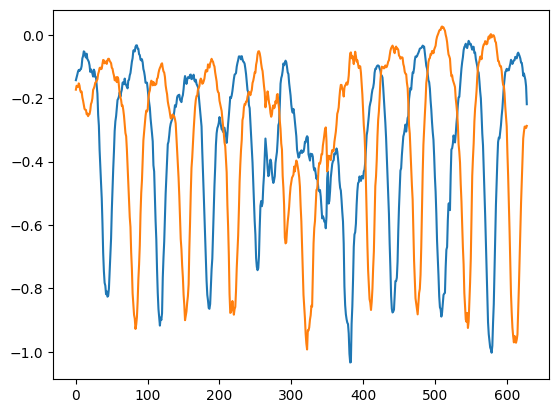

In [17]:
(state, constraints, next_states), (ang, vel, action), _ = updated_model(dataset[0], skip_vel=True, skip_action=True)
jnp.mean((state.site_xpos.shape - dataset[1]) ** 2)

# plot the knees
plt.figure()
plt.plot(ang[:, [9, 16]]);

Exception ignored in: <function Renderer.__del__ at 0x325e61260>
Traceback (most recent call last):
  File "/Users/hamzaiqbal/Documents/projects/MonocularBiomechanics/venv_py311/lib/python3.11/site-packages/mujoco/renderer.py", line 337, in __del__
    self.close()
  File "/Users/hamzaiqbal/Documents/projects/MonocularBiomechanics/venv_py311/lib/python3.11/site-packages/mujoco/renderer.py", line 325, in close
    if self._mjr_context:
       ^^^^^^^^^^^^^^^^^
AttributeError: 'Renderer' object has no attribute '_mjr_context'
Exception ignored in: <function Renderer.__del__ at 0x325e61260>
Traceback (most recent call last):
  File "/Users/hamzaiqbal/Documents/projects/MonocularBiomechanics/venv_py311/lib/python3.11/site-packages/mujoco/renderer.py", line 337, in __del__
    self.close()
  File "/Users/hamzaiqbal/Documents/projects/MonocularBiomechanics/venv_py311/lib/python3.11/site-packages/mujoco/renderer.py", line 325, in close
    if self._mjr_context:
       ^^^^^^^^^^^^^^^^^
Attrib

🔧 Fixing MuJoCo rendering...
✓ Trying MUJOCO_GL=osmesa
❌ MUJOCO_GL=osmesa failed: module 'mujoco.gl_context' has no attribute 'GLContext'
✓ Trying MUJOCO_GL=glfw
❌ MUJOCO_GL=glfw failed: module 'mujoco.gl_context' has no attribute 'GLContext'
✓ Trying MUJOCO_GL=egl
❌ MUJOCO_GL=egl failed: module 'mujoco.gl_context' has no attribute 'GLContext'
✓ Trying MUJOCO_GL=disable


Exception ignored in: <function Renderer.__del__ at 0x325e61260>
Traceback (most recent call last):
  File "/Users/hamzaiqbal/Documents/projects/MonocularBiomechanics/venv_py311/lib/python3.11/site-packages/mujoco/renderer.py", line 337, in __del__
    self.close()
  File "/Users/hamzaiqbal/Documents/projects/MonocularBiomechanics/venv_py311/lib/python3.11/site-packages/mujoco/renderer.py", line 325, in close
    if self._mjr_context:
       ^^^^^^^^^^^^^^^^^
AttributeError: 'Renderer' object has no attribute '_mjr_context'


❌ MUJOCO_GL=disable failed: module 'mujoco.gl_context' has no attribute 'GLContext'
⚠️  All MuJoCo GL backends failed. Using alternative visualization.
⚠️  MuJoCo rendering failed. Using alternative visualization.
Use the alternative_render_trajectory function instead.

📊 Available functions:
- create_simple_visualization(ang, filename): Creates static plots
- alternative_render_trajectory(ang, filename): Creates animated visualization
- fix_mujoco_rendering(): Tries to fix MuJoCo rendering
✓ Saved plot to trajectory_analysis.png


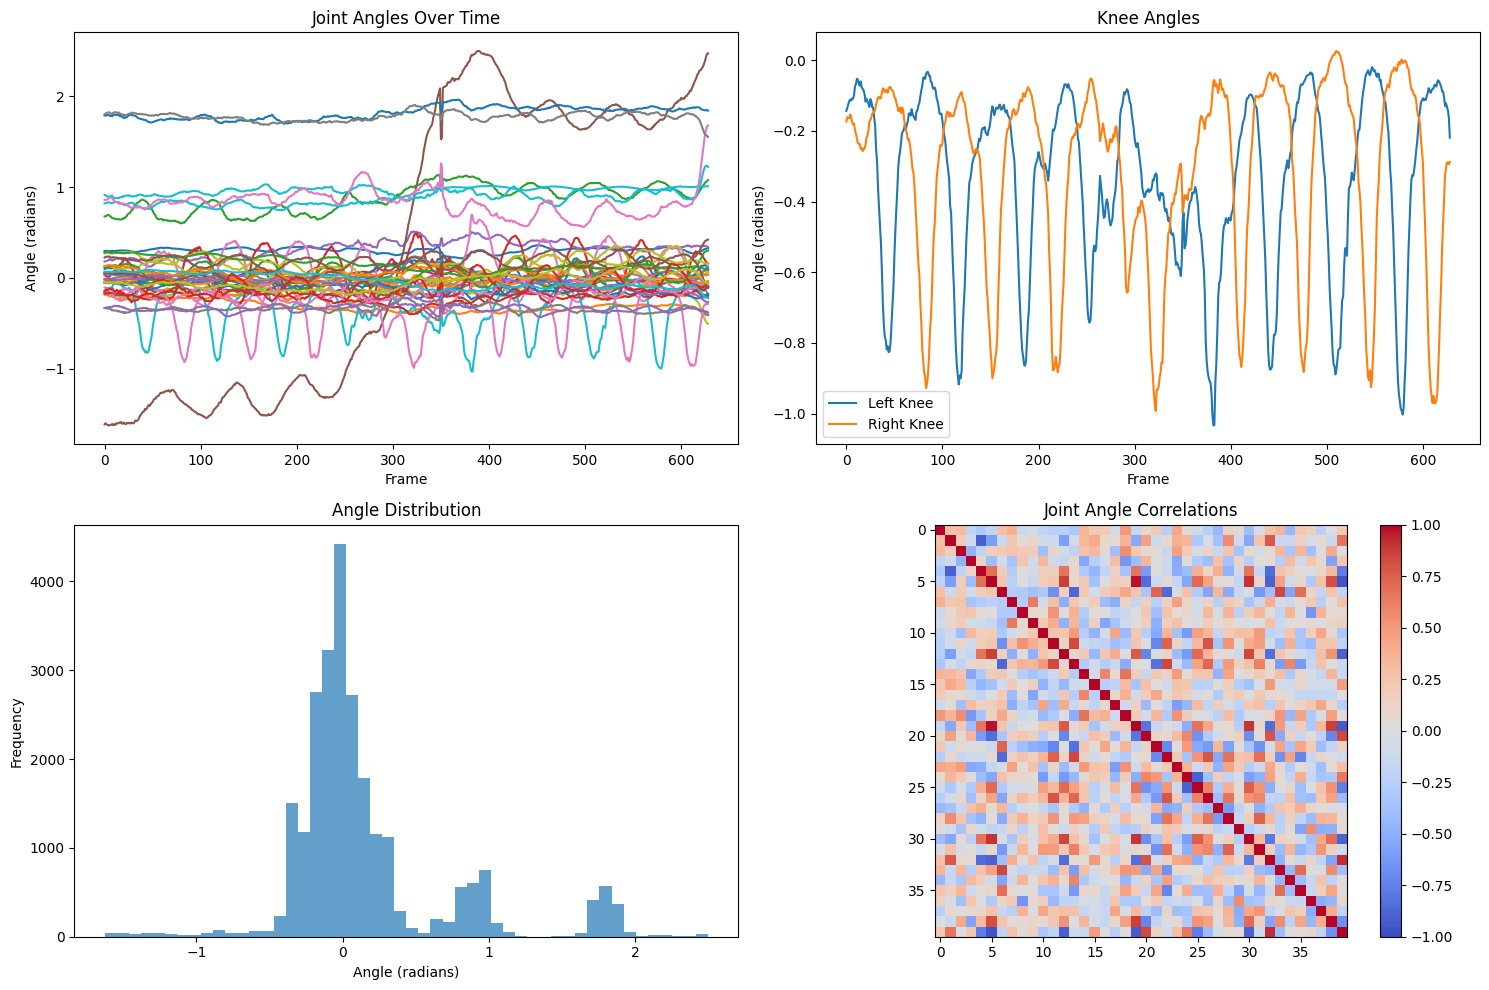

Animation creation failed: unknown file extension: .mp4
Falling back to simple plotting...
✓ Saved plot to trajectory_analysis.png


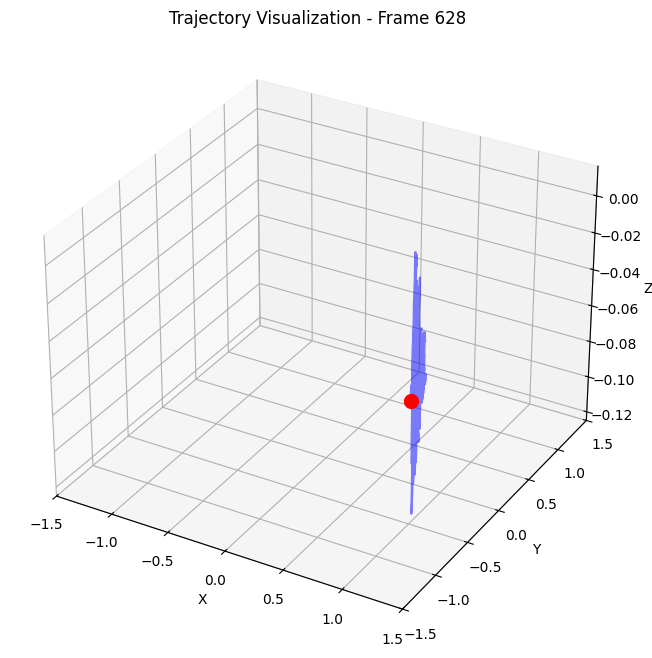

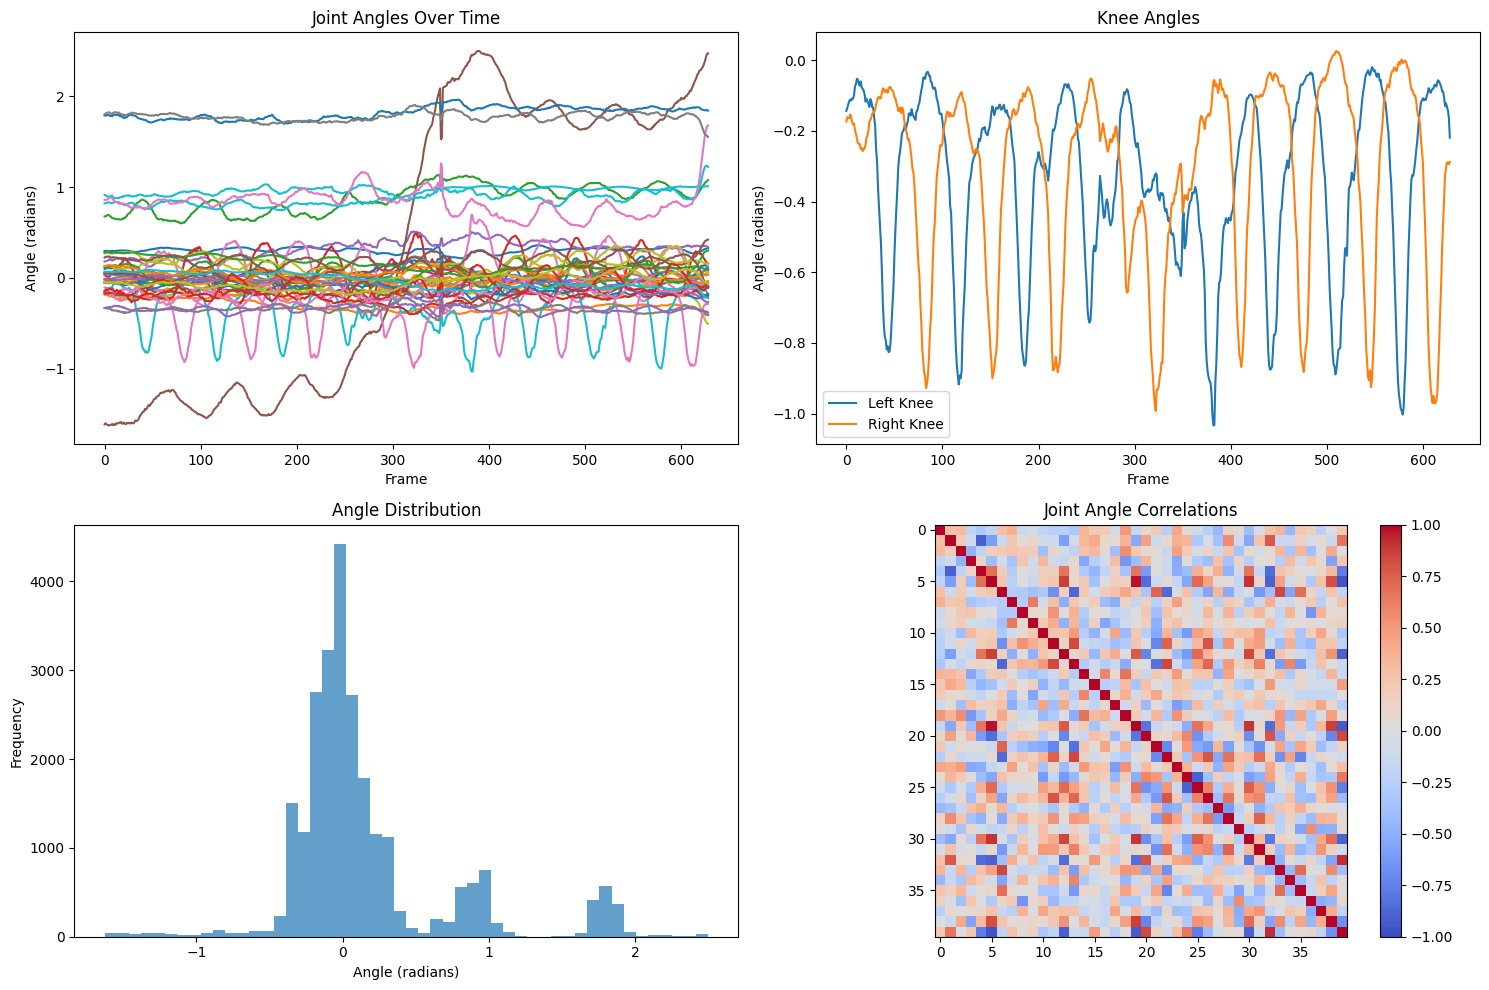

In [26]:
# Use alternative visualization since MuJoCo rendering failed
from notebook_rendering_fix import create_simple_visualization, alternative_render_trajectory

# Create static plots of your trajectory data
create_simple_visualization(ang, 'trajectory_analysis.png')

# Create an animated visualization
alternative_render_trajectory(ang, 'reconstruction.mp4')

# Display the video in the notebook
from IPython.display import HTML
HTML = HTML(f'<video controls><source src="reconstruction.mp4" type="video/mp4"></video>')
HTML